# Custom Values Notebook

This notebook computes custom values for supply chain configuration from raw data.

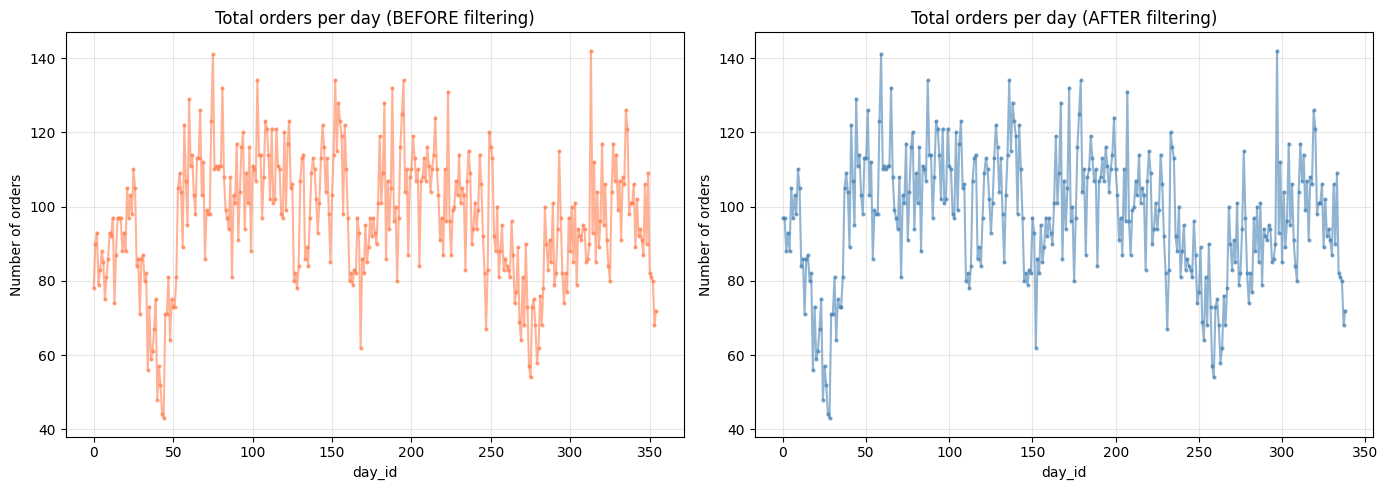

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW_DATA_PATH = Path("../../../data_files/raw")

# Load orders and order_sku_demand
orders_df = pd.read_csv(RAW_DATA_PATH / "08_orders.csv")
order_sku_demand_df = pd.read_csv(RAW_DATA_PATH / "09_order_sku_demand.csv")

# Orders per day BEFORE filtering
orders_per_day_before = orders_df.groupby("day_id").size().reset_index(name="n_orders")

# Remove day_id 0-15 and 371-385 (user wrote 385-371, interpreted as 371-385)
orders_df = orders_df[
    ~((orders_df["day_id"] >= 0) & (orders_df["day_id"] <= 15))
    & ~((orders_df["day_id"] >= 371) & (orders_df["day_id"] <= 386))
]

# Get removed salesorderids and filter order_sku_demand
valid_salesorderids = set(orders_df["salesorderid"])
order_sku_demand_df = order_sku_demand_df[
    order_sku_demand_df["salesorderid"].isin(valid_salesorderids)
]

# Renumber day_id to start from 0 (contiguous 0, 1, 2, ...)
old_to_new_day = {old: new for new, old in enumerate(sorted(orders_df["day_id"].unique()))}
orders_df["day_id"] = orders_df["day_id"].map(old_to_new_day)

# Orders per day AFTER filtering
orders_per_day_after = orders_df.groupby("day_id").size().reset_index(name="n_orders")

# Plot before and after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(orders_per_day_before["day_id"], orders_per_day_before["n_orders"], marker="o", markersize=2, alpha=0.6, color="coral")
axes[0].set_title("Total orders per day (BEFORE filtering)")
axes[0].set_xlabel("day_id")
axes[0].set_ylabel("Number of orders")
axes[0].grid(True, alpha=0.3)

axes[1].plot(orders_per_day_after["day_id"], orders_per_day_after["n_orders"], marker="o", markersize=2, alpha=0.6, color="steelblue")
axes[1].set_title("Total orders per day (AFTER filtering)")
axes[1].set_xlabel("day_id")
axes[1].set_ylabel("Number of orders")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# Remove regions with less than 100 total orders across all timesteps
region_order_counts = orders_df.groupby("regionid").size()
regions_to_keep = region_order_counts[region_order_counts >= 100].index.tolist()
regions_removed = region_order_counts[region_order_counts < 100].index.tolist()

orders_df = orders_df[orders_df["regionid"].isin(regions_to_keep)]
valid_salesorderids = set(orders_df["salesorderid"])
order_sku_demand_df = order_sku_demand_df[order_sku_demand_df["salesorderid"].isin(valid_salesorderids)]

# Renumber regionid and region_index to start from 0 (contiguous)
regions_df = pd.read_csv(RAW_DATA_PATH / "02_regions.csv")
regions_df = regions_df[regions_df["regionid"].isin(regions_to_keep)].sort_values("region_index").reset_index(drop=True)
old_to_new_regionid = {old: f"R_{i:04d}" for i, old in enumerate(regions_df["regionid"])}
regions_df["regionid"] = regions_df["regionid"].map(old_to_new_regionid)
regions_df["region_index"] = np.arange(len(regions_df))
orders_df["regionid"] = orders_df["regionid"].map(old_to_new_regionid)

print(f"Regions removed: {len(regions_removed)}")
print(f"Regions remaining: {len(regions_to_keep)}")

Regions removed: 0
Regions remaining: 15


In [4]:
# Save all adjustments from cells 1 and 2 as CSVs in data_files (not data_files/raw) with original names
DATA_FILES_PATH = Path("../../../data_files")

orders_df.to_csv(DATA_FILES_PATH / "08_orders.csv", index=False)
order_sku_demand_df.to_csv(DATA_FILES_PATH / "09_order_sku_demand.csv", index=False)

# Save filtered and renumbered regions from cell 2
regions_df.to_csv(DATA_FILES_PATH / "02_regions.csv", index=False)

print(f"Saved 02_regions.csv, 08_orders.csv, 09_order_sku_demand.csv to {DATA_FILES_PATH}")

Saved 02_regions.csv, 08_orders.csv, 09_order_sku_demand.csv to ..\..\..\data_files


In [5]:
# Demand analysis for specified SKUs
TARGET_SKUS = ["SKU_03340", "SKU_10375", "SKU_03566"]

sku_demand_with_day = order_sku_demand_df.merge(
    orders_df[["salesorderid", "day_id", "regionid"]], on="salesorderid", how="inner"
)
sku_demand_filtered = sku_demand_with_day[sku_demand_with_day["itemid"].isin(TARGET_SKUS)]

# Metrics per SKU
sku_stats = sku_demand_filtered.groupby("itemid").agg(
    total_quantity=("quantity", "sum"),
    n_orders=("salesorderid", "nunique"),
    n_active_timesteps=("day_id", "nunique"),
    avg_quantity_per_order=("quantity", "mean"),
    min_quantity=("quantity", "min"),
    max_quantity=("quantity", "max"),
).reset_index()

sku_stats["avg_quantity_per_timestep"] = sku_stats["total_quantity"] / sku_stats["n_active_timesteps"]
total_timesteps = sku_demand_with_day["day_id"].nunique()
sku_stats["pct_active_timesteps"] = (sku_stats["n_active_timesteps"] / total_timesteps * 100).round(1)

# Per-region breakdown for these SKUs
region_sku_stats = sku_demand_filtered.groupby(["itemid", "regionid"]).agg(
    total_quantity=("quantity", "sum"),
    n_orders=("salesorderid", "nunique"),
    n_active_timesteps=("day_id", "nunique"),
).reset_index()

print("Demand analysis for SKU_02786, SKU_10375, SKU_03566")
print("=" * 80)
print(f"Total timesteps in dataset: {total_timesteps}")
print("\nPer-SKU summary:")
print(sku_stats.to_string(index=False))
print("\nPer-SKU per-region breakdown:")
print(region_sku_stats.to_string(index=False))

Demand analysis for SKU_02786, SKU_10375, SKU_03566
Total timesteps in dataset: 339

Per-SKU summary:
   itemid  total_quantity  n_orders  n_active_timesteps  avg_quantity_per_order  min_quantity  max_quantity  avg_quantity_per_timestep  pct_active_timesteps
SKU_03340         2342905     10991                 339              213.165772             1         34773                6911.224189                 100.0
SKU_03566         2017410     11705                 339              172.354549             1         21595                5951.061947                 100.0
SKU_10375         2707163      7780                 339              347.964396             1         69338                7985.731563                 100.0

Per-SKU per-region breakdown:
   itemid regionid  total_quantity  n_orders  n_active_timesteps
SKU_03340   R_0000           87011       307                 209
SKU_03340   R_0002           12108        86                  75
SKU_03340   R_0003          109563       422

In [6]:
def print_mean_orders_per_day(region_id=None, filter_sku_ids=None):
    """
    Prints mean number of orders per day_id for each remaining region.
    region_id: None = all regions; int/str = single region; list = array of region ids.
    filter_sku_ids: None = all orders; single item id or list = only orders containing at least one of these SKUs.
    """
    df = orders_df.copy()
    if filter_sku_ids is not None:
        ids = [filter_sku_ids] if np.isscalar(filter_sku_ids) else list(filter_sku_ids)
        orders_with_sku = order_sku_demand_df[order_sku_demand_df["itemid"].isin(ids)]["salesorderid"].unique()
        df = df[df["salesorderid"].isin(orders_with_sku)]

    mean_orders = df.groupby("regionid").apply(
        lambda g: g.groupby("day_id").size().mean()
    ).reset_index(name="mean_orders_per_day")

    if region_id is not None:
        ids = [region_id] if np.isscalar(region_id) else list(region_id)
        mean_orders = mean_orders[mean_orders["regionid"].isin(ids)]

    print(mean_orders.to_string(index=False))

# Example: display all
# print_mean_orders_per_day(region_id=None)

TARGET_REGIONS = ["R_0004", "R_0005", "R_0014"]
# Example: filter by SKUs (uncomment to use)
print_mean_orders_per_day(region_id=TARGET_REGIONS, filter_sku_ids=TARGET_SKUS)

regionid  mean_orders_per_day
  R_0004            19.386431
  R_0005            14.675516
  R_0014             1.200000


C:\Users\Jakob Ehrenhuber\AppData\Local\Temp\ipykernel_46992\120449574.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_orders = df.groupby("regionid").apply(


In [7]:
def print_mean_unique_skus_per_order(region_id=None, filter_sku_ids=None):
    """
    lambda_skus[r]: Filter to orders containing at least one selected SKU, then for each such order
    count only how many of the selected SKUs appear in it. Take the mean of those counts. Result in [1, N].
    region_id: None = all regions; int/str = single region; list = array of region ids.
    filter_sku_ids: None = all orders, count all SKUs; single or list = only orders with selected SKUs, count only selected SKUs.
    """
    merged = order_sku_demand_df.merge(
        orders_df[["salesorderid", "day_id", "regionid"]], on="salesorderid", how="inner"
    )

    if filter_sku_ids is not None:
        ids = [filter_sku_ids] if np.isscalar(filter_sku_ids) else list(filter_sku_ids)
        orders_with_sku = merged[merged["itemid"].isin(ids)]["salesorderid"].unique()
        merged = merged[merged["salesorderid"].isin(orders_with_sku)]
        # Count only selected SKUs per order (not all SKUs)
        merged = merged[merged["itemid"].isin(ids)]

    skus_per_order = merged.groupby(["salesorderid", "day_id", "regionid"]).agg(
        n_unique_skus=("itemid", "nunique")
    ).reset_index()

    mean_skus = skus_per_order.groupby("regionid").apply(
        lambda g: g.groupby("day_id")["n_unique_skus"].mean().mean()
    ).reset_index(name="mean_unique_skus_per_order_per_day")

    if region_id is not None:
        ids = [region_id] if np.isscalar(region_id) else list(region_id)
        mean_skus = mean_skus[mean_skus["regionid"].isin(ids)]

    print(mean_skus.to_string(index=False))

# Example: display all, all orders
# print_mean_unique_skus_per_order(region_id=None, filter_sku_ids=None)

# Example: filter by SKU (uncomment to use)
print_mean_unique_skus_per_order(region_id=TARGET_REGIONS, filter_sku_ids=TARGET_SKUS)

C:\Users\Jakob Ehrenhuber\AppData\Local\Temp\ipykernel_46992\200085977.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mean_skus = skus_per_order.groupby("regionid").apply(


regionid  mean_unique_skus_per_order_per_day
  R_0004                            1.884419
  R_0005                            2.024985
  R_0014                            1.600000


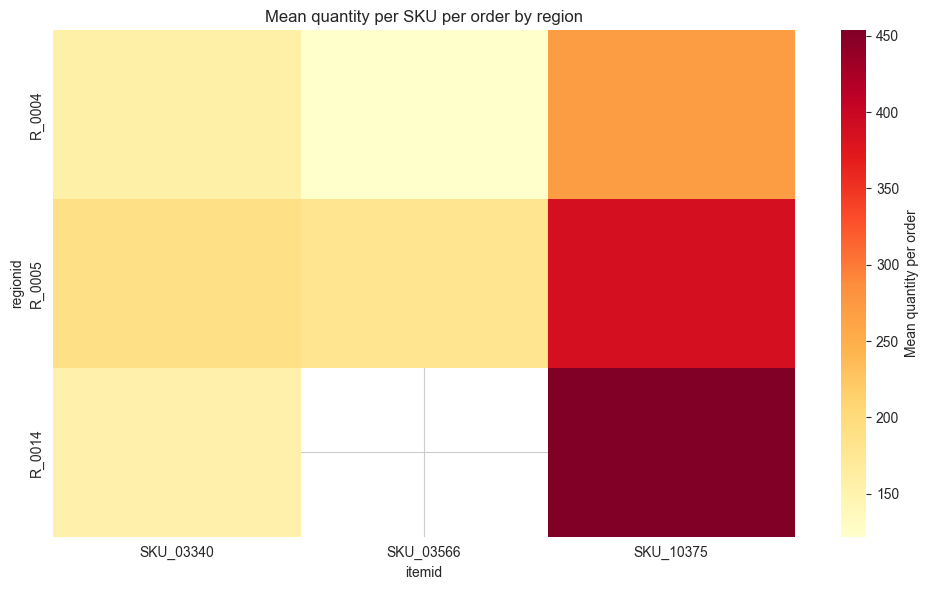

regionid    itemid  mean_quantity_per_order
  R_0004 SKU_03340               158.184061
  R_0004 SKU_03566               121.928364
  R_0004 SKU_10375               269.671013
  R_0005 SKU_03340               189.190966
  R_0005 SKU_03566               181.186449
  R_0005 SKU_10375               386.433998
  R_0014 SKU_03340               153.666667
  R_0014 SKU_10375               453.500000


In [8]:
def visualize_mean_quantity_per_sku(region_id=None, filter_sku_ids=None):
    """
    lambda_quantity[r,s]: Filter to orders containing selected SKU s, then take the mean quantity of SKU s across those orders.
    region_id: None = all regions; single or list of region ids to filter.
    filter_sku_ids: None = all SKUs; single or list = only compute for these SKUs.
    """
    merged = order_sku_demand_df.merge(
        orders_df[["salesorderid", "regionid"]], on="salesorderid", how="inner"
    )

    if region_id is not None:
        ids = [region_id] if np.isscalar(region_id) else list(region_id)
        merged = merged[merged["regionid"].isin(ids)]

    if filter_sku_ids is not None:
        ids = [filter_sku_ids] if np.isscalar(filter_sku_ids) else list(filter_sku_ids)
        merged = merged[merged["itemid"].isin(ids)]

    # For each (region, itemid): mean quantity of that SKU over orders that contain it
    mean_qty = (
        merged.groupby(["regionid", "itemid"])["quantity"]
        .mean()
        .reset_index(name="mean_quantity_per_order")
    )

    pivot = mean_qty.pivot(index="regionid", columns="itemid", values="mean_quantity_per_order")

    # If too many SKUs/regions, show subset or aggregate view
    n_regions, n_skus = pivot.shape
    if n_skus > 50 or n_regions > 30:
        # Show top SKUs by total mean quantity
        top_skus = mean_qty.groupby("itemid")["mean_quantity_per_order"].sum().nlargest(30).index
        pivot = pivot[[c for c in pivot.columns if c in top_skus]]
        plt.figure(figsize=(14, max(6, n_regions * 0.3)))
    else:
        plt.figure(figsize=(max(10, n_skus * 0.3), max(6, n_regions * 0.3)))

    sns.set_style("whitegrid")
    sns.heatmap(pivot, annot=False, cmap="YlOrRd", fmt=".1f", cbar_kws={"label": "Mean quantity per order"})
    plt.title("Mean quantity per SKU per order by region")
    plt.tight_layout()
    plt.show()

    # Print region-SKU pairs
    print(mean_qty.to_string(index=False))

visualize_mean_quantity_per_sku(region_id=TARGET_REGIONS, filter_sku_ids=TARGET_SKUS)

In [9]:
def print_unit_cost(item_id=None):
    """
    Prints unit cost from table skus.
    item_id: None = all SKUs; single or list of item ids to filter.
    """
    skus_df = pd.read_csv(RAW_DATA_PATH / "06_skus.csv")
    result = skus_df[["itemid", "unitcost"]].copy()
    result = result.rename(columns={"unitcost": "unit_cost"})

    if item_id is not None:
        ids = [item_id] if np.isscalar(item_id) else list(item_id)
        result = result[result["itemid"].isin(ids)]

    print(result.to_string(index=False))

# Example: all
# print_unit_cost(item_id=None)

# Example: specific SKU (uncomment to use)
print_unit_cost(item_id=TARGET_SKUS)

   itemid  unit_cost
SKU_03566   0.962503
SKU_03340   1.060664
SKU_10375   0.898622


In [10]:
def print_warehouse_sku_costs(item_id=None, node_id=None, region_id=None):
    """
    Prints for each warehouse-SKU pair: inbound fixed/variable, and for each warehouse-region: outbound fixed/variable.
    item_id: None = all SKUs; single or list to filter.
    node_id: None = all warehouses; single or list to filter.
    region_id: None = all regions; single or list to filter outbound costs.
    """
    skus_df = pd.read_csv(RAW_DATA_PATH / "06_skus.csv")
    stw_df = pd.read_csv(RAW_DATA_PATH / "05_supplier_to_warehouse.csv")
    wtr_df = pd.read_csv(RAW_DATA_PATH / "03_warehouse_to_region.csv")
    sps_df = pd.read_csv(RAW_DATA_PATH / "07_skus_per_supplier.csv")
    warehouses_df = pd.read_csv(RAW_DATA_PATH / "01_warehouses.csv")
    regions_df = pd.read_csv(RAW_DATA_PATH / "02_regions.csv")

    # Inbound: (warehouse, SKU) -> use closest supplier by distance_km per SKU
    sku_supplier = sps_df.groupby("itemid")["supplierid"].apply(list).to_dict()
    lane_map = stw_df.set_index(["sourcesupplierid", "destinationnodeid"])

    inbound_rows = []
    for _, wh in warehouses_df.iterrows():
        nodeid = wh["nodeid"]
        if node_id is not None:
            nids = [node_id] if np.isscalar(node_id) else list(node_id)
            if nodeid not in nids:
                continue
        for _, sku_row in skus_df.iterrows():
            itemid = sku_row["itemid"]
            if item_id is not None:
                iids = [item_id] if np.isscalar(item_id) else list(item_id)
                if itemid not in iids:
                    continue
            suppliers = sku_supplier.get(itemid, [])
            best_fix, best_var = np.nan, np.nan
            best_dist = np.inf
            for sid in suppliers:
                key = (sid, nodeid)
                if key in lane_map.index:
                    row = lane_map.loc[key]
                    dist = row["distance_km"]
                    if dist < best_dist:
                        best_dist = dist
                        best_fix = row["fixed_costs"]
                        best_var = row["variable_costs_per_weight"]
            inbound_rows.append({
                "nodeid": nodeid, "itemid": itemid,
                "inbound_fixed": best_fix, "inbound_variable": best_var
            })

    inbound_df = pd.DataFrame(inbound_rows)

    # Outbound: (warehouse, region)
    outbound_df = wtr_df.rename(columns={
        "sourcenodeid": "nodeid", "destinationregionid": "regionid",
        "fixed_costs": "outbound_fixed", "variable_costs_per_weight": "outbound_variable"
    })[["nodeid", "regionid", "outbound_fixed", "outbound_variable"]]

    if node_id is not None:
        nids = [node_id] if np.isscalar(node_id) else list(node_id)
        outbound_df = outbound_df[outbound_df["nodeid"].isin(nids)]

    if region_id is not None:
        rids = [region_id] if np.isscalar(region_id) else list(region_id)
        outbound_df = outbound_df[outbound_df["regionid"].isin(rids)]

    print("Inbound (warehouse, SKU):")
    print(inbound_df.head(50).to_string(index=False))
    if len(inbound_df) > 50:
        print(f"... ({len(inbound_df)} rows total)")
    print("\nOutbound (warehouse, region):")
    print(outbound_df.head(50).to_string(index=False))
    if len(outbound_df) > 50:
        print(f"... ({len(outbound_df)} rows total)")

TARGET_WH = ["N_00016", "N_00004", "N_00012"]
# Example: specify item id(s), warehouse(s), region(s)
print_warehouse_sku_costs(item_id=TARGET_SKUS, node_id=TARGET_WH, region_id=TARGET_REGIONS)

Inbound (warehouse, SKU):
 nodeid    itemid  inbound_fixed  inbound_variable
N_00016 SKU_03566     140.317833          0.361145
N_00016 SKU_03340     148.655608          0.186959
N_00016 SKU_10375     148.655608          0.186959
N_00012 SKU_03566     555.629035          1.126562
N_00012 SKU_03340     492.897254          0.607808
N_00012 SKU_10375     681.305175          1.235985
N_00004 SKU_03566     117.537152          0.443874
N_00004 SKU_03340     117.537152          0.443874
N_00004 SKU_10375     117.537152          0.443874

Outbound (warehouse, region):
 nodeid regionid  outbound_fixed  outbound_variable
N_00016   R_0005      698.196243           0.479191
N_00016   R_0004      412.787126           0.417811
N_00016   R_0014      315.653504           0.645413
N_00012   R_0004      655.463028           1.397502
N_00012   R_0014      761.706803           1.261084
N_00012   R_0005      671.305524           1.427728
N_00004   R_0004      610.868093           0.354875
N_00004   R_0005 

In [11]:
def print_penalty_cost(item_id):
    """
    Prints penalty_cost(s) = 5 * unit_cost(s) for specified single or array of item ids.
    """
    skus_df = pd.read_csv(RAW_DATA_PATH / "06_skus.csv")
    ids = [item_id] if np.isscalar(item_id) else list(item_id)
    subset = skus_df[skus_df["itemid"].isin(ids)][["itemid", "unitcost"]].copy()
    subset["penalty_cost"] = 1.25* subset["unitcost"]
    print(subset.to_string(index=False))

# Example: specify item id(s)
print_penalty_cost(item_id=TARGET_SKUS)

   itemid  unitcost  penalty_cost
SKU_03566  0.962503      1.203128
SKU_03340  1.060664      1.325830
SKU_10375  0.898622      1.123278


In [12]:
def print_max_order_quantity(sku_ids, region_id=None):
    """
    For each specified SKU: 90th percentile of total demand per timestep across all regions and timesteps.
    Prints max_order_quantity[s] = rounded value.
    region_id: None = all regions; single or list to filter.
    """
    merged = order_sku_demand_df.merge(
        orders_df[["salesorderid", "day_id", "regionid"]], on="salesorderid", how="inner"
    )
    ids = [sku_ids] if np.isscalar(sku_ids) else list(sku_ids)
    merged = merged[merged["itemid"].isin(ids)]
    if region_id is not None:
        rids = [region_id] if np.isscalar(region_id) else list(region_id)
        merged = merged[merged["regionid"].isin(rids)]

    total_demand_per_timestep = merged.groupby(["itemid", "day_id"])["quantity"].sum().reset_index()
    quantiles = [0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
    q_df = total_demand_per_timestep.groupby("itemid")["quantity"].quantile(quantiles).unstack(level=1)
    q_df = q_df.round().astype(int)
    q_df.columns = [f"p{int(q*100)}" for q in quantiles]
    q_df["max_order_quantity"] = q_df["p90"] / 3
    print(q_df.to_string())

# Example: specify SKU(s)
print_max_order_quantity(sku_ids=TARGET_SKUS, region_id=TARGET_REGIONS)   

            p25   p50   p75   p90    p95    p99  max_order_quantity
itemid                                                             
SKU_03340  2116  3117  5048  7517  10485  17190         2505.666667
SKU_03566  1677  2832  4386  7671  10099  17579         2557.000000
SKU_10375  2416  3854  6162  9904  15298  37970         3301.333333


In [20]:
def compute_warehouse_sku_lead_time_and_inventory(
    warehouse_ids=None, sku_ids=None, region_ids=None
):
    """
    For each (warehouse, SKU) pair, compute:
    ids = [item_id] if np.isscalar(item_id) else list(item_id)
    subset = skus_df[skus_df["itemid"].isin(ids)][["itemid", "unitcost"]].copy()
    subset["penalty_cost"] = 5 * subset["unitcost"]
    print(subset.to_string(index=False))

    """
    warehouse_ids = warehouse_ids or TARGET_WH
    sku_ids = sku_ids or TARGET_SKUS
    region_ids = region_ids or TARGET_REGIONS

    N = len(sku_ids)
    stw_df = pd.read_csv(RAW_DATA_PATH / "05_supplier_to_warehouse.csv")
    sps_df = pd.read_csv(RAW_DATA_PATH / "07_skus_per_supplier.csv")

    # Compute lambdas from data (filtered to selected SKUs and regions)
    merged = order_sku_demand_df.merge(
        orders_df[["salesorderid", "day_id", "regionid"]], on="salesorderid", how="inner"
    )
    merged = merged[merged["itemid"].isin(sku_ids) & merged["regionid"].isin(region_ids)]

    orders_with_sku = merged["salesorderid"].unique()
    orders_filtered = orders_df[
        orders_df["salesorderid"].isin(orders_with_sku)
        & orders_df["regionid"].isin(region_ids)
    ]

    orders_per_day = orders_filtered.groupby(["regionid", "day_id"]).size().reset_index(name="n")
    lambda_orders_r = orders_per_day.groupby("regionid")["n"].mean().to_dict()
    lambda_orders_r['R_0014'] = 14

    skus_per_order = merged.groupby(["salesorderid", "day_id", "regionid"]).agg(
        n_skus=("itemid", "nunique")
    ).reset_index()
    lambda_skus_r = skus_per_order.groupby("regionid")["n_skus"].mean().to_dict()
    for key in lambda_skus_r.keys():
        lambda_skus_r[key] = 2/3

    lambda_qty_rs = merged.groupby(["regionid", "itemid"])["quantity"].mean()
    lane_map = stw_df.set_index(["sourcesupplierid", "destinationnodeid"])
    sku_supplier = sps_df.groupby("itemid")["supplierid"].apply(list).to_dict()
    lambda_qty_rs['R_0014', 'SKU_03566'] = 137


    print(f"lambda_orders_r: {lambda_orders_r}")
    print(f"lambda_skus_r: {lambda_skus_r}")
    print(f"lambda_qty_rs: {lambda_qty_rs}")



    rows = []
    for nid in warehouse_ids:
        for iid in sku_ids:
            suppliers = sku_supplier.get(iid, [])
            lt = np.nan
            best_dist = np.inf
            for sid in suppliers:
                key = (sid, nid)
                if key in lane_map.index:
                    dist = lane_map.loc[key, "distance_km"]
                    if dist < best_dist:
                        best_dist = dist
                        lt = lane_map.loc[key, "shippingtime_days"]
            if np.isnan(lt):
                continue

            sum_r = 0.0
            for r in region_ids:
                lo = lambda_orders_r.get(r, 0.0)
                ls = lambda_skus_r.get(r, 0.0)
                lq = lambda_qty_rs.get((r, iid), 0.0)
                sum_r += lo * ls * lq

                      
            inv = round((sum_r/3))
            rows.append({"nodeid": nid, "itemid": iid, "lead_time_days": lt, "initial_inventory": inv})

    return pd.DataFrame(rows)


df_result = compute_warehouse_sku_lead_time_and_inventory()
print(df_result.to_string(index=False))
df_result

lambda_orders_r: {'R_0004': 19.386430678466077, 'R_0005': 14.67551622418879, 'R_0014': 14}
lambda_skus_r: {'R_0004': 0.6666666666666666, 'R_0005': 0.6666666666666666, 'R_0014': 0.6666666666666666}
lambda_qty_rs: regionid  itemid   
R_0004    SKU_03340    158.184061
          SKU_03566    121.928364
          SKU_10375    269.671013
R_0005    SKU_03340    189.190966
          SKU_03566    181.186449
          SKU_10375    386.433998
R_0014    SKU_03340    153.666667
          SKU_10375    453.500000
          SKU_03566    137.000000
Name: quantity, dtype: float64
 nodeid    itemid  lead_time_days  initial_inventory
N_00016 SKU_03340               1               1777
N_00016 SKU_10375               1               3833
N_00016 SKU_03566               1               1542
N_00004 SKU_03340               1               1777
N_00004 SKU_10375               1               3833
N_00004 SKU_03566               1               1542
N_00012 SKU_03340               2               1777
N_00012

,nodeid,itemid,lead_time_days,initial_inventory
0,N_00016,SKU_03340,1,1777
1,N_00016,SKU_10375,1,3833
2,N_00016,SKU_03566,1,1542
3,N_00004,SKU_03340,1,1777
4,N_00004,SKU_10375,1,3833
5,N_00004,SKU_03566,1,1542
6,N_00012,SKU_03340,2,1777
7,N_00012,SKU_10375,10,3833
8,N_00012,SKU_03566,11,1542
